# Lab 7: Data-Driven Bike Sharing System Simulation

Welcome to **Lab 7** of the Modeling & Simulation course! In this lab, we will enhance our bike-sharing system simulation by incorporating real-world data. We will use the **London bike-sharing dataset** to extract meaningful patterns and probabilities, which we will then integrate into our simulation model. This approach will allow us to simulate various scenarios, such as days with bad weather or holidays, and analyze their impact on the bike-sharing system.

---


## Table of Contents

1. [Introduction](#introduction)
2. [Dataset Overview](#dataset-overview)
3. [Data Exploration](#data-exploration)
   - [Loading the Dataset](#loading-the-dataset)
   - [Exploratory Data Analysis](#exploratory-data-analysis)
4. [Integrating Data into the Simulation](#integrating-data)
   - [Adjusting Trip Probabilities](#adjusting-trip-probabilities)
   - [Modifying the Simulation Model](#modifying-simulation)
5. [Simulation Scenarios](#simulation-scenarios)
   - [Simulating a Day with Bad Weather](#bad-weather-simulation)
   - [Simulating a Holiday](#holiday-simulation)

---


## <a name="introduction"></a>1. Introduction

In previous labs, we developed a bike-sharing system simulation using SimPy, modeling stations, bikes, and trips between stations. However, our model used simplified assumptions and fixed probabilities for trip generation, which may not accurately reflect real-world usage patterns.

In this lab, we will enhance our simulation by:

- **Incorporating real-world data**: We will use the `london_merged.csv` dataset, which contains historical data from a bike-sharing system in London.
- **Performing data exploration**: Analyzing the dataset to discover patterns and probabilities related to bike usage.
- **Adjusting the simulation model**: Modifying our simulation to use the extracted probabilities, allowing us to simulate different scenarios.
- **Exploring simulation scenarios**: Running simulations under various conditions, such as bad weather or holidays, to observe their impact on the system.

---


## <a name="dataset-overview"></a>2. Dataset Overview

The `london_merged.csv` dataset contains the following columns:

- `timestamp`: Timestamp for grouping the data.
- `cnt`: Count of new bike shares (number of bikes rented during the hour).
- `t1`: Real temperature in °C.
- `t2`: "Feels like" temperature in °C.
- `hum`: Humidity percentage.
- `wind_speed`: Wind speed in km/h.
- `weather_code`: Category of the weather:
  - `1`: Clear or mostly clear.
  - `2`: Scattered clouds or few clouds.
  - `3`: Broken clouds.
  - `4`: Cloudy.
  - `7`: Rain or light rain shower.
  - `10`: Rain with thunderstorm.
  - `26`: Snowfall.
  - `94`: Freezing fog.
- `is_holiday`: Boolean field (`1` for holiday, `0` for non-holiday).
- `is_weekend`: Boolean field (`1` if the day is a weekend).
- `season`: Meteorological season (`0`: Spring, `1`: Summer, `2`: Fall, `3`: Winter).

---


## <a name="data-exploration"></a>3. Data Exploration

### <a name="loading-the-dataset"></a>Loading the Dataset

First, we need to load the dataset into a pandas DataFrame.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data = pd.read_csv('london_merged.csv', parse_dates=['timestamp'])

# Display the first few rows
data.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


### <a name="exploratory-data-analysis"></a>Exploratory Data Analysis

#### 3.1 Bike Usage Over Time

Let's visualize the total bike usage over time.

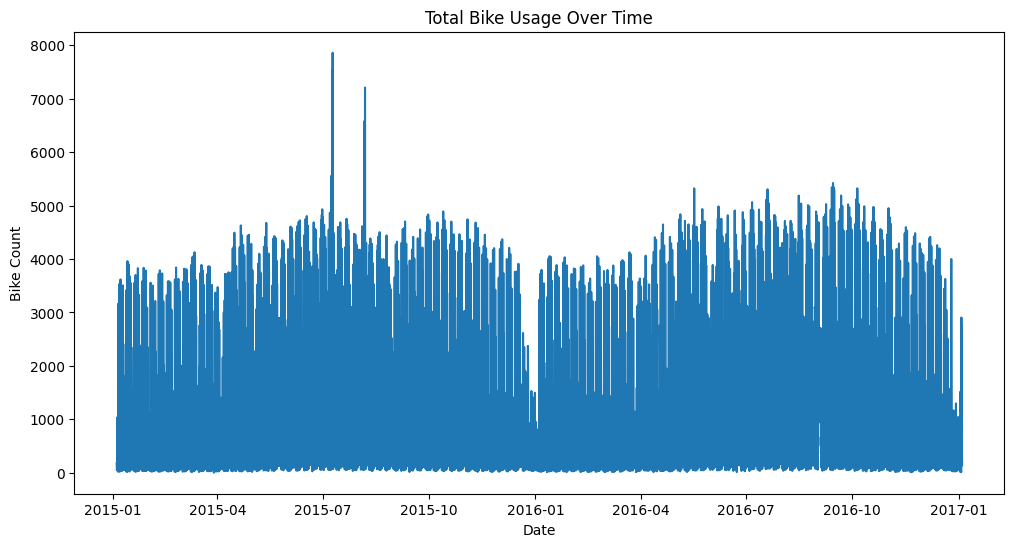

In [2]:
# Plot total bike usage over time
plt.figure(figsize=(12, 6))
plt.plot(data['timestamp'], data['cnt'])
plt.title('Total Bike Usage Over Time')
plt.xlabel('Date')
plt.ylabel('Bike Count')
plt.show()


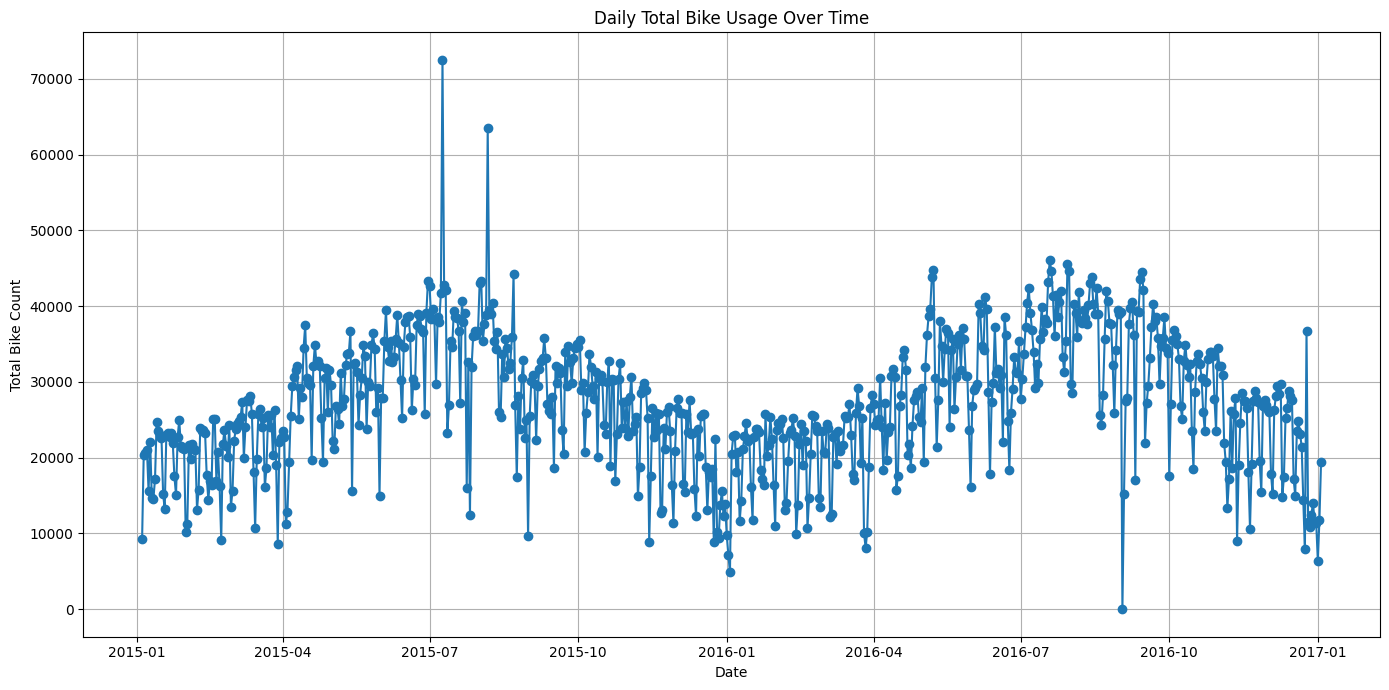

In [3]:
# Resample data to daily averages for better granularity
daily_data = data.set_index('timestamp').resample('D').sum()

# Plot total bike usage over time
plt.figure(figsize=(14, 7))
plt.plot(daily_data.index, daily_data['cnt'], marker='o', linestyle='-')
plt.title('Daily Total Bike Usage Over Time')
plt.xlabel('Date')
plt.ylabel('Total Bike Count')
plt.grid(True)
plt.tight_layout()
plt.show()


#### 3.2 Impact of Weather on Bike Usage

Let's analyze how different weather conditions affect bike usage.


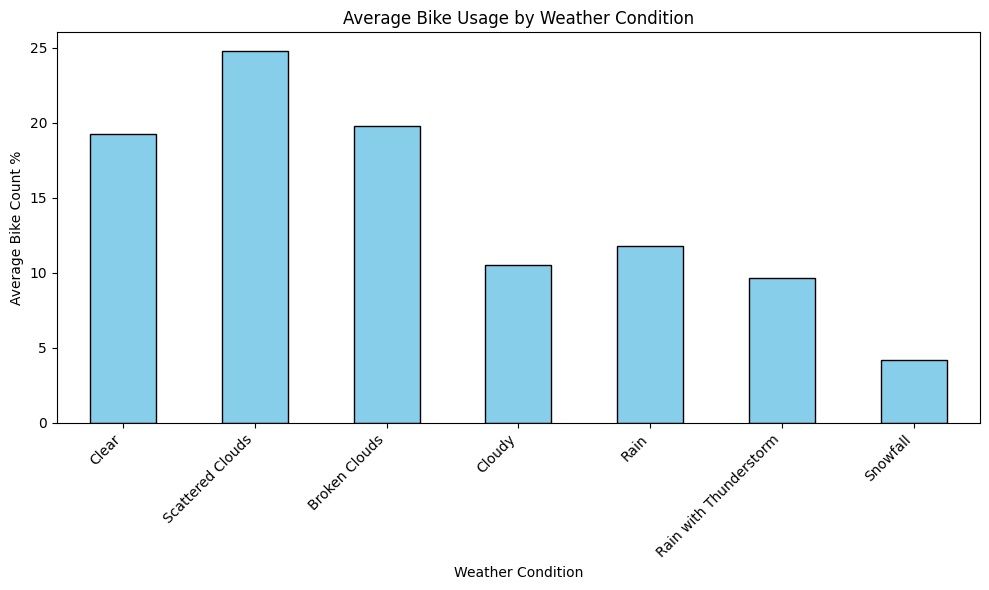

In [4]:
# Group data by weather_code and calculate average bike count in percentage
weather_group = data.groupby('weather_code')['cnt'].mean().sort_index()
weather_group = weather_group / weather_group.sum() * 100

# Define weather labels for better readability
weather_labels = {
    1: 'Clear',
    2: 'Scattered Clouds',
    3: 'Broken Clouds',
    4: 'Cloudy',
    7: 'Rain',
    10: 'Rain with Thunderstorm',
    26: 'Snowfall',
    94: 'Freezing Fog'
}

# Map weather codes to labels
weather_group.index = weather_group.index.map(weather_labels)

# Plot average bike count for each weather condition
plt.figure(figsize=(10, 6))
weather_group.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Bike Usage by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Bike Count %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### 3.3 Impact of Holidays and Weekends

Analyze the effect of holidays and weekends on bike usage.


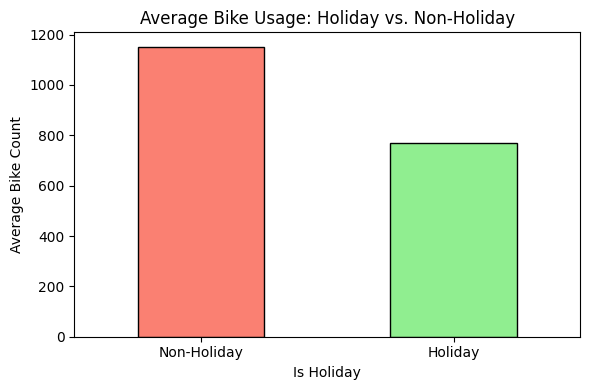

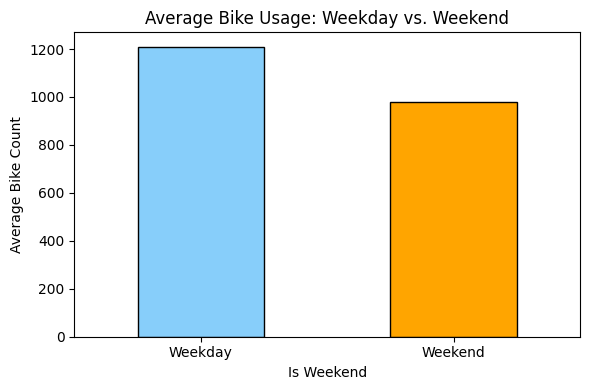

In [5]:
# Average bike usage on holidays vs. non-holidays
holiday_group = data.groupby('is_holiday')['cnt'].mean()

# Plot
plt.figure(figsize=(6, 4))
holiday_group.plot(kind='bar', color=['salmon', 'lightgreen'], edgecolor='black')
plt.title('Average Bike Usage: Holiday vs. Non-Holiday')
plt.xlabel('Is Holiday')
plt.ylabel('Average Bike Count')
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'], rotation=0)
plt.tight_layout()
plt.show()

# Average bike usage on weekends vs. weekdays
weekend_group = data.groupby('is_weekend')['cnt'].mean()

# Plot
plt.figure(figsize=(6, 4))
weekend_group.plot(kind='bar', color=['lightskyblue', 'orange'], edgecolor='black')
plt.title('Average Bike Usage: Weekday vs. Weekend')
plt.xlabel('Is Weekend')
plt.ylabel('Average Bike Count')
plt.xticks([0, 1], ['Weekday', 'Weekend'], rotation=0)
plt.tight_layout()
plt.show()


#### 3.4 Correlation with Temperature

Examine the relationship between temperature and bike usage.


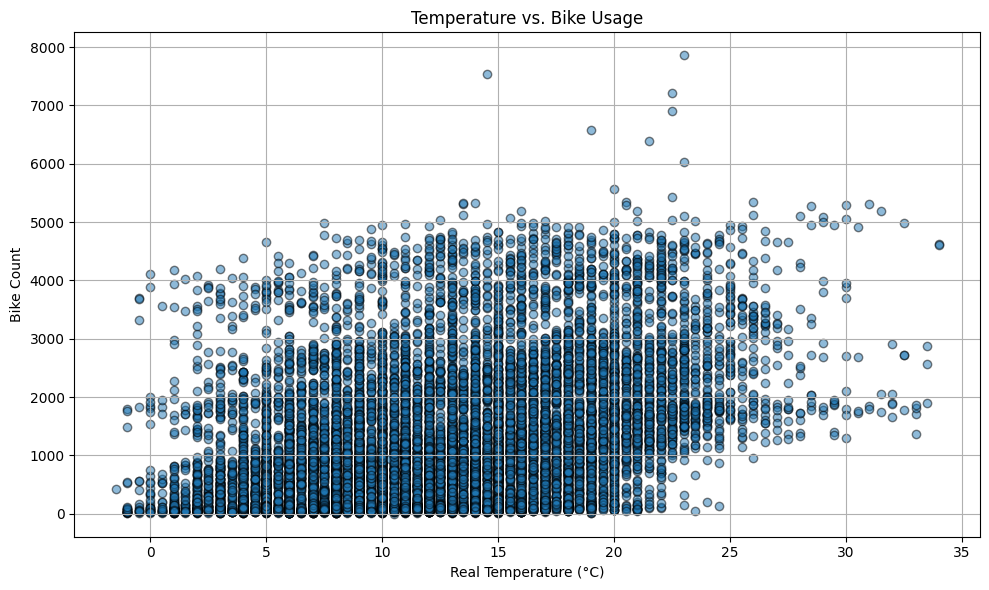

Correlation between temperature and bike usage: 0.39


In [6]:
# Scatter plot of real temperature vs. bike count
plt.figure(figsize=(10, 6))
plt.scatter(data['t1'], data['cnt'], alpha=0.5, edgecolor='k')
plt.title('Temperature vs. Bike Usage')
plt.xlabel('Real Temperature (°C)')
plt.ylabel('Bike Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate correlation
corr = data['t1'].corr(data['cnt'])
print(f"Correlation between temperature and bike usage: {corr:.2f}")

**Observation**: There is a positive correlation between temperature and bike usage, indicating that warmer temperatures generally lead to higher bike rentals.

---


## <a name="integrating-data"></a>4. Integrating Data into the Simulation

### <a name="adjusting-trip-probabilities"></a>Adjusting Trip Probabilities

Based on our data exploration, we can adjust the trip probabilities in our simulation model according to factors such as weather, holidays, and weekends.


#### 4.1 Calculating Probabilities

For simplicity, we'll calculate the average bike usage under different conditions as a proportion of the maximum usage and use these factors to adjust trip probabilities.


In [7]:
# Maximum average bike count
max_avg_cnt = data.groupby('weather_code')['cnt'].mean().max()

# Function to calculate adjustment factor
def calculate_adjustment_factor(condition_data):
    avg_cnt = condition_data['cnt'].mean()
    return avg_cnt / max_avg_cnt

# Adjustment factors for weather conditions
weather_factors = data.groupby('weather_code').apply(calculate_adjustment_factor).to_dict()

# Adjustment factors for holidays and weekends
holiday_factor = calculate_adjustment_factor(data[data['is_holiday'] == 1])
non_holiday_factor = calculate_adjustment_factor(data[data['is_holiday'] == 0])

weekend_factor = calculate_adjustment_factor(data[data['is_weekend'] == 1])
weekday_factor = calculate_adjustment_factor(data[data['is_weekend'] == 0])

# Display adjustment factors
print("Weather Factors:")
for code, factor in weather_factors.items():
    print(f"  {weather_labels.get(code, 'Unknown')}: {factor:.2f}")

print(f"\nHoliday Factor: {holiday_factor:.2f}")
print(f"Non-Holiday Factor: {non_holiday_factor:.2f}")

print(f"\nWeekend Factor: {weekend_factor:.2f}")
print(f"Weekday Factor: {weekday_factor:.2f}")


Weather Factors:
  Clear: 0.78
  Scattered Clouds: 1.00
  Broken Clouds: 0.80
  Cloudy: 0.42
  Rain: 0.48
  Rain with Thunderstorm: 0.39
  Snowfall: 0.17

Holiday Factor: 0.51
Non-Holiday Factor: 0.77

Weekend Factor: 0.65
Weekday Factor: 0.81


C:\Users\daria\AppData\Local\Temp\ipykernel_9804\324324048.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weather_factors = data.groupby('weather_code').apply(calculate_adjustment_factor).to_dict()


#### <a name="modifying-simulation"></a>4.2 Modifying the Simulation Model
Now that we have calculated the adjustment factors, we can integrate them into our simulation model. We will adjust the base trip probabilities according to the conditions we want to simulate (e.g., bad weather, holiday).




###### 4.2.1 Adjusting Trip Probabilities
Our simulation uses a base prob_matrix that defines the base probabilities of trips between stations. We will adjust these probabilities using the factors we've calculated from the data.

Let's define a function to adjust the probabilities:

In [8]:
def adjust_probabilities(base_probs, factors):
    adjusted_probs = {}
    for key, base_prob in base_probs.items():
        adjusted_prob = base_prob
        for factor in factors.values():
            adjusted_prob *= factor
        adjusted_probs[key] = adjusted_prob
    return adjusted_probs

In [9]:
!pip install simpy
# if simpy not already installed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


##### 4.2.1 Updating our simulation code

In [10]:
import simpy
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data = pd.read_csv('london_merged.csv', parse_dates=['timestamp'])

# Maximum bike count in the dataset
max_cnt = data['cnt'].max()

# Function to calculate probability adjustment factor
def calculate_adjustment_factor(condition_data):
    avg_cnt = condition_data['cnt'].mean()
    return avg_cnt / max_cnt

# Adjustment factors for weather conditions
weather_factors = data.groupby('weather_code').apply(calculate_adjustment_factor).to_dict()

# Adjustment factors for holiday and weekend
holiday_factor = calculate_adjustment_factor(data[data['is_holiday'] == 1])
non_holiday_factor = calculate_adjustment_factor(data[data['is_holiday'] == 0])
weekday_factor = calculate_adjustment_factor(data[data['is_weekend'] == 0])
weekend_factor = calculate_adjustment_factor(data[data['is_weekend'] == 1])

# Function to adjust probabilities
def adjust_probabilities(base_probs, factors):
    adjusted_probs = {}
    for key, base_prob in base_probs.items():
        adjusted_prob = base_prob
        for factor in factors.values():
            adjusted_prob *= factor
        adjusted_probs[key] = adjusted_prob
    return adjusted_probs

# Define the Station class
class Station:
    def __init__(self, env, name, capacity, init_bikes):
        self.env = env
        self.name = name
        self.capacity = capacity
        self.bikes = simpy.Container(env, init=init_bikes, capacity=capacity)

# Define the bike_trip function
def bike_trip(env, from_station, to_station):
    global unhappy_customers
    # Attempt to get a bike from the starting station
    if from_station.bikes.level > 0:
        yield from_station.bikes.get(1)
        # print(f"Time {env.now}: Bike taken from {from_station.name}")
    else:
        # print(f"Time {env.now}: No bikes available at {from_station.name}")
        unhappy_customers += 1
        return  # Trip cannot proceed without a bike

    # Simulate random trip duration
    trip_duration = random.uniform(5, 15)  # Random duration between 5 and 15 minutes
    yield env.timeout(trip_duration)

    # Attempt to return the bike to the destination station
    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
        # print(f"Time {env.now}: Bike returned to {to_station.name}")
    else:
        # print(f"Time {env.now}: No docks available at {to_station.name}")
        unhappy_customers += 1
        # For simplicity, the bike is not returned in this case

# Define the generate_trips function
def generate_trips(env, prob_matrix):
    while True:
        # Decide whether a trip occurs based on adjusted probabilities
        for (from_station, to_station), prob in prob_matrix.items():
            if random.uniform(0, 1) < prob:
                env.process(bike_trip(env, from_station, to_station))
        yield env.timeout(1)  # Wait for 1 minute before checking again

# Define the monitor_stations function
def monitor_stations(env, stations, bike_levels):
    while True:
        for station in stations:
            bike_levels[station.name].append((env.now, station.bikes.level))
        yield env.timeout(1)

# Define the rebalance_bikes function
def rebalance_bikes(env, stations):
    while True:
        # Simple rebalancing logic:
        low_bike_stations = [s for s in stations if s.bikes.level < s.capacity * 0.3]
        high_bike_stations = [s for s in stations if s.bikes.level > s.capacity * 0.7]

        for low_station in low_bike_stations:
            for high_station in high_bike_stations:
                if high_station.bikes.level > 0 and low_station.bikes.level < low_station.capacity:
                    yield high_station.bikes.get(1)
                    yield env.timeout(1)  # Time taken to move the bike
                    yield low_station.bikes.put(1)
                    # print(f"Time {env.now}: Rebalanced a bike from {high_station.name} to {low_station.name}")
        yield env.timeout(15)  # Rebalance every 15 minutes

# Function to run the simulation
def run_simulation(factors, title):
    global unhappy_customers
    unhappy_customers = 0

    # Initialize the environment
    env = simpy.Environment()

    # Create stations
    upt_station = Station(env, "UPT", capacity=10, init_bikes=5)
    center_station = Station(env, "Center", capacity=10, init_bikes=5)
    park_station = Station(env, "Park", capacity=8, init_bikes=4)
    stations = [upt_station, center_station, park_station]

    # Define base trip probabilities
    base_prob_matrix = {
        (upt_station, center_station): 0.3,
        (center_station, upt_station): 0.5,
        (upt_station, park_station): 0.2,
        (park_station, upt_station): 0.1,
        (center_station, park_station): 0.3,
        (park_station, center_station): 0.4,
    }

    # Adjust probabilities using the provided factors
    adjusted_prob_matrix = adjust_probabilities(base_prob_matrix, factors)

    # Initialize data collection
    bike_levels = {station.name: [] for station in stations}

    # Start processes
    env.process(generate_trips(env, adjusted_prob_matrix))
    env.process(monitor_stations(env, stations, bike_levels))
    env.process(rebalance_bikes(env, stations))

    # Run the simulation
    env.run(until=24 * 60)  # Run for 24 hours (in minutes)

    # Plotting bike levels over time
    plt.figure(figsize=(12, 6))
    for station_name, levels in bike_levels.items():
        times, counts = zip(*levels)
        plt.plot(times, counts, label=station_name)

    plt.xlabel('Time (minutes)')
    plt.ylabel('Number of Bikes')
    plt.title(f'Bike Levels at Each Station Over Time ({title})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Output the number of unhappy customers
    print(f"Number of unhappy customers during {title.lower()}: {unhappy_customers}")


C:\Users\daria\AppData\Local\Temp\ipykernel_9804\2899696397.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weather_factors = data.groupby('weather_code').apply(calculate_adjustment_factor).to_dict()


## <a name="simulation-scenarios"></a>5. Testing Simulation Scenarios

### <a name="bad-weather-simulation"></a> Scenario: Bad Weather (Rain - Weather Code 7)


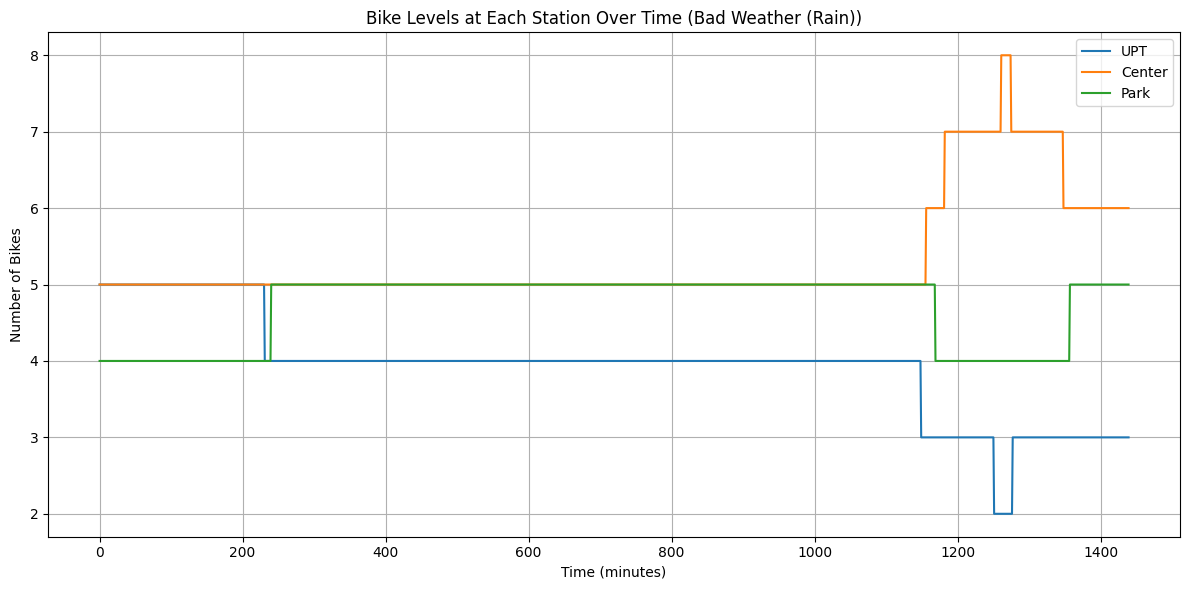

Number of unhappy customers during bad weather (rain): 0


In [11]:
# Scenario: Bad Weather (Rain - Weather Code 7)

# Weather adjustment factor for code 7 (Rain)
weather_factor = weather_factors[7]

# Assume it's a weekday and not a holiday
factors_bad_weather = {
    'weather': weather_factor,
    'holiday': non_holiday_factor,  # Not a holiday
    'weekend': weekday_factor,      # Weekday
}

# Run the simulation
run_simulation(factors_bad_weather, title="Bad Weather (Rain)")

### <a name="holiday-simulation"></a> Scenario: Holiday (Assuming Clear Weather)


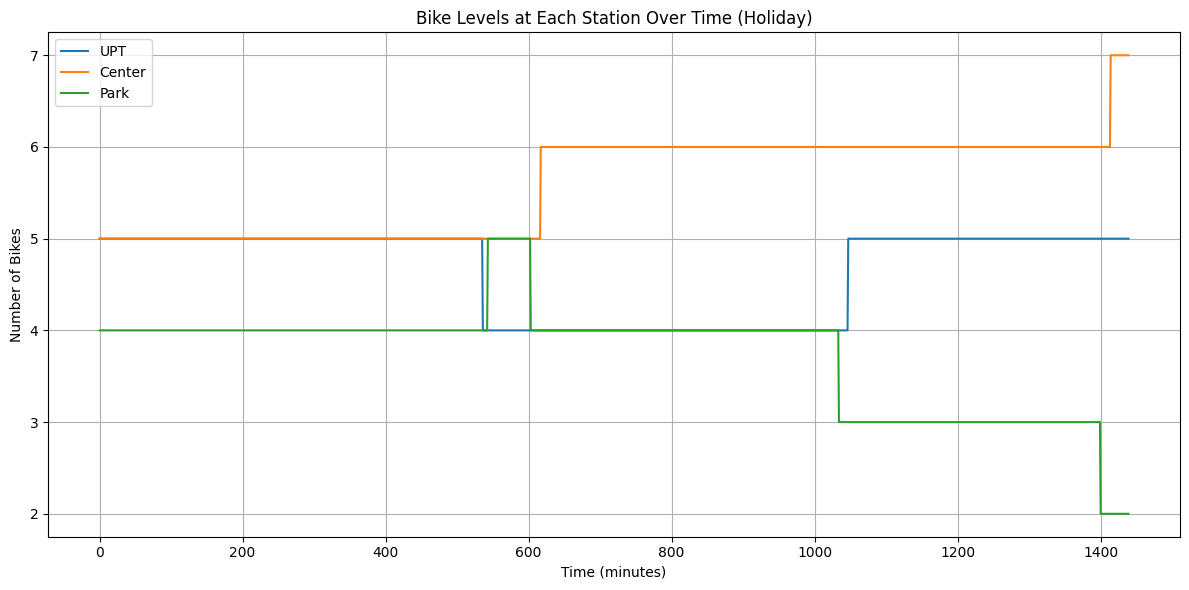

Number of unhappy customers during holiday: 0


In [12]:
# Scenario: Holiday (Assuming Clear Weather)

# Weather adjustment factor for code 1 (Clear)
weather_factor = weather_factors[1]

# Holiday adjustment factors
factors_holiday = {
    'weather': weather_factor,
    'holiday': holiday_factor,      # It's a holiday
    'weekend': weekend_factor,      # Assuming the holiday is on a weekend
}

# Run the simulation
run_simulation(factors_holiday, title="Holiday")

### Pattern analysis
Run simulation for longer time periods to observe impact of our new data factors

Starting simulation: Bad Weather (Rain) for 10 days with minute frequency.
Simulation completed: Bad Weather (Rain)



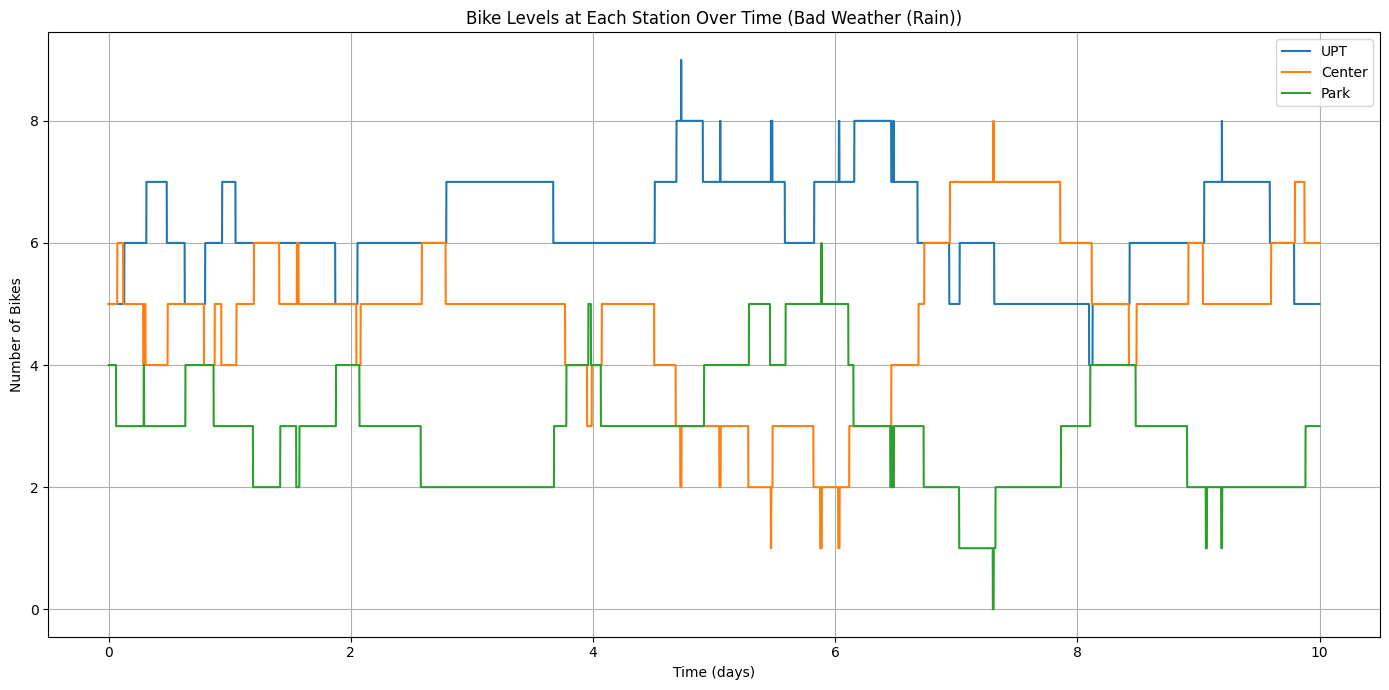

Number of unhappy customers during bad weather (rain): 0
Starting simulation: Holiday for 10 days with minute frequency.
Simulation completed: Holiday



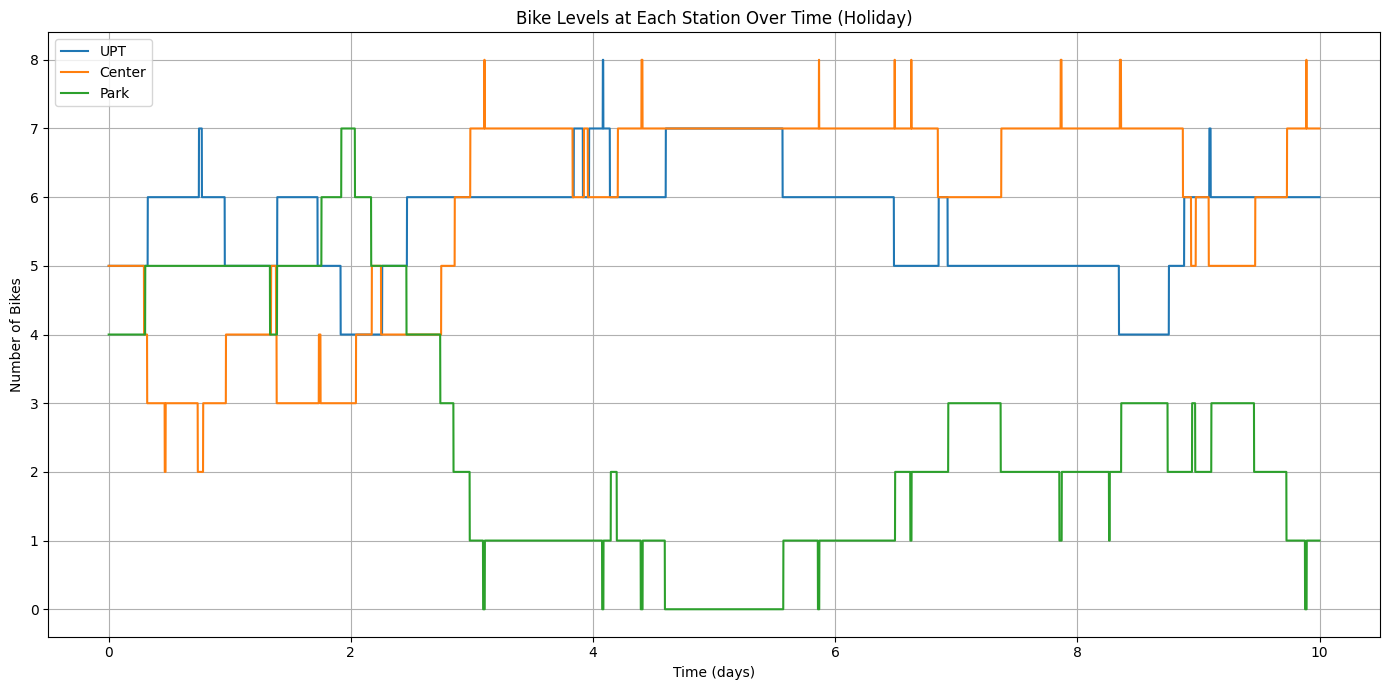

Number of unhappy customers during holiday: 0


In [13]:
# Extended Simulation for Longer Periods and Higher Frequency

import simpy
import matplotlib.pyplot as plt

# Define simulation parameters
simulation_days = 10  # Number of days to simulate
time_unit = 'minute'  # 'minute' or 'second' for frequency

# Convert simulation duration based on time unit
if time_unit == 'minute':
    simulation_duration = simulation_days * 24 * 60  # Duration in minutes
    trip_duration_min = True
elif time_unit == 'second':
    simulation_duration = simulation_days * 24 * 60 * 60  # Duration in seconds
    trip_duration_min = False
else:
    raise ValueError("Invalid time_unit. Choose 'minute' or 'second'.")

# Adjust trip duration based on frequency
def get_trip_duration():
    if trip_duration_min:
        return random.uniform(5, 15)  # 5 to 15 minutes
    else:
        return random.uniform(300, 900)  # 5 to 15 minutes in seconds

# Modify the bike_trip function to use the new trip duration
def bike_trip_extended(env, from_station, to_station):
    global unhappy_customers
    # Attempt to get a bike from the starting station
    if from_station.bikes.level > 0:
        yield from_station.bikes.get(1)
    else:
        unhappy_customers += 1
        return  # Trip cannot proceed without a bike

    # Simulate trip duration
    trip_duration = get_trip_duration()
    yield env.timeout(trip_duration)

    # Attempt to return the bike to the destination station
    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
    else:
        unhappy_customers += 1
        # Bike is not returned if no dock is available

# Modify the generate_trips function to use the extended bike_trip
def generate_trips_extended(env, prob_matrix):
    while True:
        for (from_station, to_station), prob in prob_matrix.items():
            if random.uniform(0, 1) < prob:
                env.process(bike_trip_extended(env, from_station, to_station))
        yield env.timeout(1)  # Time step remains consistent

# Redefine the run_simulation function to accept duration and frequency
def run_simulation_extended(factors, title, duration, frequency='minute'):
    global unhappy_customers
    unhappy_customers = 0

    # Initialize the environment
    env = simpy.Environment()

    # Create stations
    upt_station = Station(env, "UPT", capacity=10, init_bikes=5)
    center_station = Station(env, "Center", capacity=10, init_bikes=5)
    park_station = Station(env, "Park", capacity=8, init_bikes=4)
    stations = [upt_station, center_station, park_station]

    # Define base trip probabilities
    base_prob_matrix = {
        (upt_station, center_station): 0.3,
        (center_station, upt_station): 0.5,
        (upt_station, park_station): 0.2,
        (park_station, upt_station): 0.1,
        (center_station, park_station): 0.3,
        (park_station, center_station): 0.4,
    }

    # Adjust probabilities using the provided factors
    adjusted_prob_matrix = adjust_probabilities(base_prob_matrix, factors)

    # Initialize data collection
    bike_levels = {station.name: [] for station in stations}

    # Start processes
    env.process(generate_trips_extended(env, adjusted_prob_matrix))
    env.process(monitor_stations(env, stations, bike_levels))
    env.process(rebalance_bikes(env, stations))

    # Run the simulation
    print(f"Starting simulation: {title} for {simulation_days} days with {frequency} frequency.")
    env.run(until=duration)
    print(f"Simulation completed: {title}\n")

    # Plotting bike levels over time
    plt.figure(figsize=(14, 7))
    for station_name, levels in bike_levels.items():
        times, counts = zip(*levels)
        # Convert time to days if frequency is second
        if frequency == 'second':
            times = [t / (24 * 60 * 60) for t in times]  # Convert seconds to days
            plt.plot(times, counts, label=station_name)
        else:
            times = [t / (24 * 60) for t in times]  # Convert minutes to days
            plt.plot(times, counts, label=station_name)

    plt.xlabel('Time (days)')
    plt.ylabel('Number of Bikes')
    plt.title(f'Bike Levels at Each Station Over Time ({title})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Output the number of unhappy customers
    print(f"Number of unhappy customers during {title.lower()}: {unhappy_customers}")

# Define scenarios with extended simulation

# Scenario 1: Bad Weather (Rain - Weather Code 7)
weather_factor_rain = weather_factors.get(7, 1.0)  # Default to 1.0 if not found
factors_bad_weather_extended = {
    'weather': weather_factor_rain,
    'holiday': non_holiday_factor,  # Not a holiday
    'weekend': weekday_factor,      # Weekday
}

# Scenario 2: Holiday (Clear Weather)
weather_factor_clear = weather_factors.get(1, 1.0)  # Default to 1.0 if not found
factors_holiday_extended = {
    'weather': weather_factor_clear,
    'holiday': holiday_factor,      # It's a holiday
    'weekend': weekend_factor,      # Assuming the holiday is on a weekend
}

# Run both scenarios for the extended duration
run_simulation_extended(factors_bad_weather_extended,
                       title="Bad Weather (Rain)",
                       duration=simulation_duration,
                       frequency=time_unit)

run_simulation_extended(factors_holiday_extended,
                       title="Holiday",
                       duration=simulation_duration,
                       frequency=time_unit)


Starting simulation: Good Weather (Clear) for 10 days with minute frequency.
Simulation completed: Good Weather (Clear)



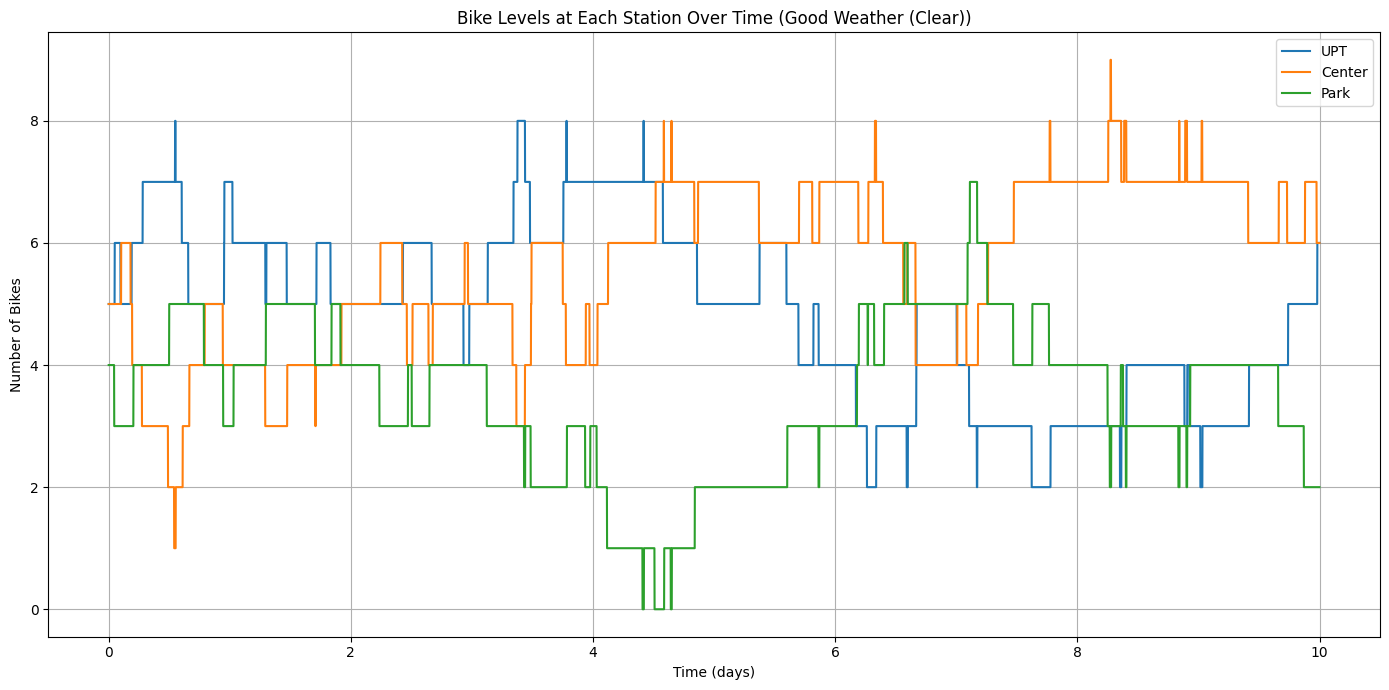

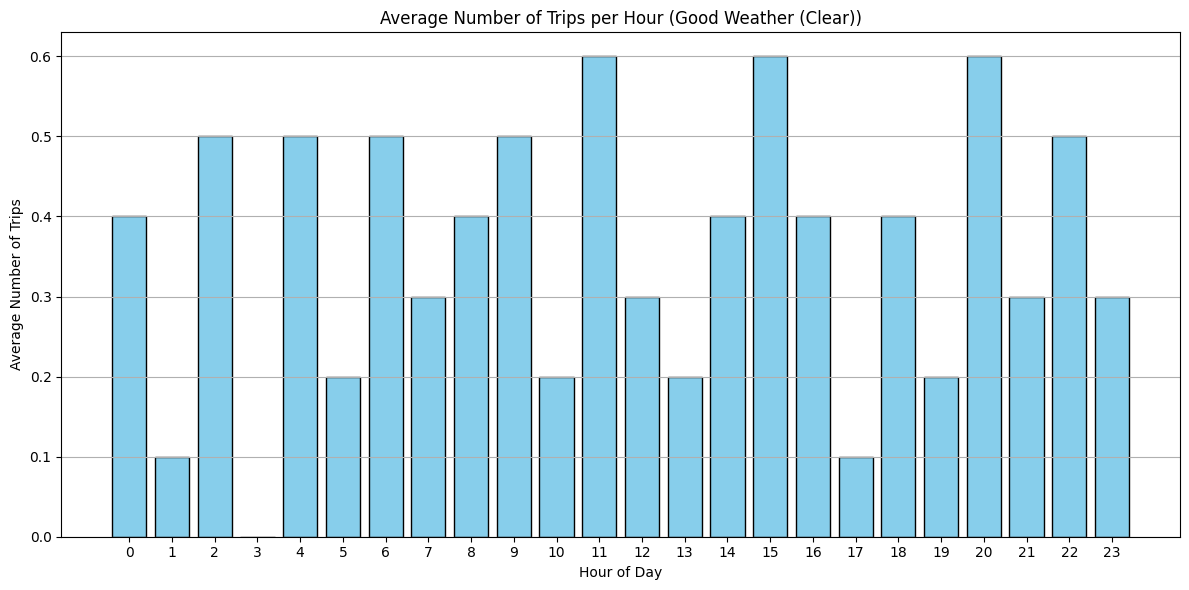

Number of unhappy customers during good weather (clear): 1
Starting simulation: Rain for 10 days with minute frequency.
Simulation completed: Rain



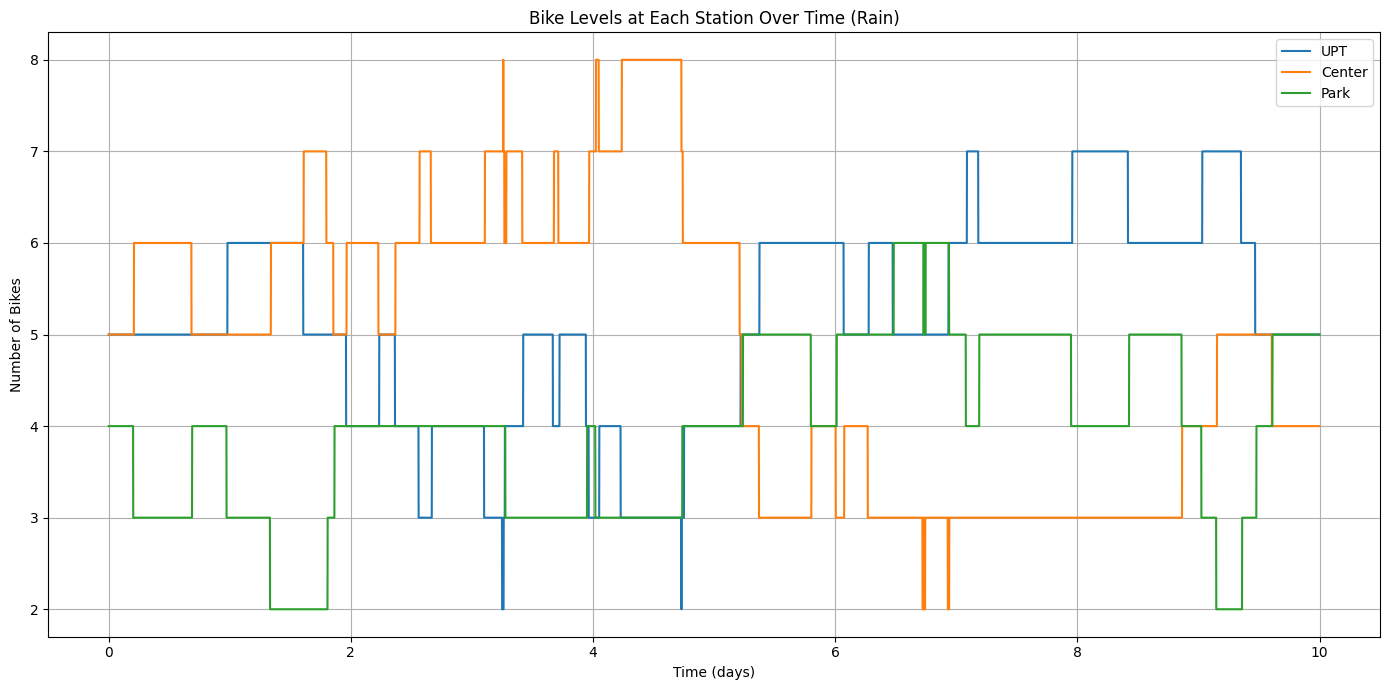

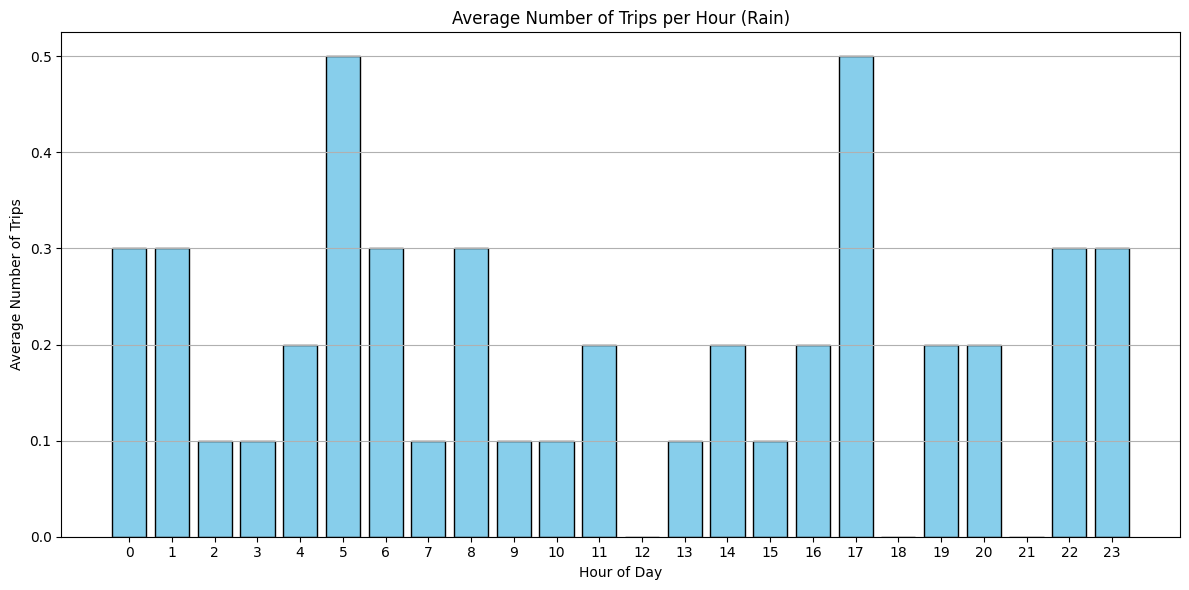

Number of unhappy customers during rain: 0


In [14]:
# Extended Simulation for Longer Periods, Higher Frequency, and Trip Counting
# Scenarios: Clear vs Rain

import simpy
import matplotlib.pyplot as plt
import random
import numpy as np

# Define simulation parameters
simulation_days = 10  # Number of days to simulate
time_unit = 'minute'  # 'minute' or 'second' for frequency

# Convert simulation duration based on time unit
if time_unit == 'minute':
    simulation_duration = simulation_days * 24 * 60  # Duration in minutes
    trip_duration_min = True
elif time_unit == 'second':
    simulation_duration = simulation_days * 24 * 60 * 60  # Duration in seconds
    trip_duration_min = False
else:
    raise ValueError("Invalid time_unit. Choose 'minute' or 'second'.")

# Adjustment trip duration based on frequency
def get_trip_duration():
    if trip_duration_min:
        return random.uniform(5, 15)  # 5 to 15 minutes
    else:
        return random.uniform(300, 900)  # 5 to 15 minutes in seconds

# Initialize trip counts per hour (0-23)
trip_counts = {hour: 0 for hour in range(24)}

# Modify the bike_trip function to use the new trip duration and count trips
def bike_trip_extended(env, from_station, to_station):
    global unhappy_customers, trip_counts
    # Attempt to get a bike from the starting station
    if from_station.bikes.level > 0:
        yield from_station.bikes.get(1)
    else:
        unhappy_customers += 1
        return  # Trip cannot proceed without a bike

    # Log the trip
    current_time = env.now
    if time_unit == 'minute':
        hour = int((current_time // 60) % 24)
    else:
        hour = int((current_time / 3600) % 24)
    trip_counts[hour] += 1

    # Simulate trip duration
    trip_duration = get_trip_duration()
    yield env.timeout(trip_duration)

    # Attempt to return the bike to the destination station
    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
    else:
        unhappy_customers += 1
        # Bike is not returned if no dock is available

# Modify the generate_trips function to use the extended bike_trip
def generate_trips_extended(env, prob_matrix):
    while True:
        for (from_station, to_station), prob in prob_matrix.items():
            if random.uniform(0, 1) < prob:
                env.process(bike_trip_extended(env, from_station, to_station))
        yield env.timeout(1)  # Time step remains consistent

# Redefine the run_simulation function to accept duration and frequency
def run_simulation_extended(factors, title, duration, frequency='minute'):
    global unhappy_customers, trip_counts
    unhappy_customers = 0
    trip_counts = {hour: 0 for hour in range(24)}  # Reset trip counts

    # Initialize the environment
    env = simpy.Environment()

    # Create stations
    upt_station = Station(env, "UPT", capacity=10, init_bikes=5)
    center_station = Station(env, "Center", capacity=10, init_bikes=5)
    park_station = Station(env, "Park", capacity=8, init_bikes=4)
    stations = [upt_station, center_station, park_station]

    # Define base trip probabilities
    base_prob_matrix = {
        (upt_station, center_station): 0.3,
        (center_station, upt_station): 0.5,
        (upt_station, park_station): 0.2,
        (park_station, upt_station): 0.1,
        (center_station, park_station): 0.3,
        (park_station, center_station): 0.4,
    }

    # Adjust probabilities using the provided factors
    adjusted_prob_matrix = adjust_probabilities(base_prob_matrix, factors)

    # Initialize data collection
    bike_levels = {station.name: [] for station in stations}

    # Start processes
    env.process(generate_trips_extended(env, adjusted_prob_matrix))
    env.process(monitor_stations(env, stations, bike_levels))
    env.process(rebalance_bikes(env, stations))

    # Run the simulation
    print(f"Starting simulation: {title} for {simulation_days} days with {frequency} frequency.")
    env.run(until=duration)
    print(f"Simulation completed: {title}\n")

    # Plotting bike levels over time
    plt.figure(figsize=(14, 7))
    for station_name, levels in bike_levels.items():
        times, counts = zip(*levels)
        # Convert time to days if frequency is second
        if frequency == 'second':
            times = [t / (24 * 60 * 60) for t in times]  # Convert seconds to days
            plt.plot(times, counts, label=station_name)
        else:
            times = [t / (24 * 60) for t in times]  # Convert minutes to days
            plt.plot(times, counts, label=station_name)

    plt.xlabel('Time (days)')
    plt.ylabel('Number of Bikes')
    plt.title(f'Bike Levels at Each Station Over Time ({title})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plotting number of trips per hour
    hours = list(trip_counts.keys())
    trips = list(trip_counts.values())
    average_trips = [trip / simulation_days for trip in trips]  # Average per day

    plt.figure(figsize=(12, 6))
    plt.bar(hours, average_trips, color='skyblue', edgecolor='black')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Number of Trips')
    plt.title(f'Average Number of Trips per Hour ({title})')
    plt.xticks(hours)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Output the number of unhappy customers
    print(f"Number of unhappy customers during {title.lower()}: {unhappy_customers}")

# Define scenarios with extended simulation

# Scenario 1: Good Weather (Clear - Weather Code 1)
weather_factor_clear = weather_factors.get(1, 1.0)  # Default to 1.0 if not found
factors_good_weather = {
    'weather': weather_factor_clear,
    'holiday': non_holiday_factor,  # Not a holiday
    'weekend': weekday_factor,      # Weekday
}

# Scenario 2: Rain (Weather Code 7)
weather_factor_rain = weather_factors.get(7, 1.0)  # Default to 1.0 if not found
factors_rain = {
    'weather': weather_factor_rain,
    'holiday': non_holiday_factor,  # Not a holiday
    'weekend': weekday_factor,      # Weekday
}

# Run both scenarios for the extended duration

# Run Good Weather Scenario
run_simulation_extended(factors_good_weather,
                       title="Good Weather (Clear)",
                       duration=simulation_duration,
                       frequency=time_unit)

# Run Rain Scenario
run_simulation_extended(factors_rain,
                       title="Rain",
                       duration=simulation_duration,
                       frequency=time_unit)


### Things to try out
* Incorporate time of day influence on the model and simulation.
* Adjust trip probabilities based on temperature and bike count correlation
* Incorporate time of week influence on the model and simulation.
* Extract other useful information from https://capitalbikeshare.com/system-data historical or live datasets